# Gradient Boosting — Health Insurance Cross-Sell

**Goal:** Predict which existing health-insurance customers will be interested in vehicle
insurance (`Response` = 1), so the company can focus its cross-sell outreach.

This notebook covers the Gradient Boosting model end to end: data preparation on the
agreed feature set, training with class-imbalance handling, evaluation, and a
business-oriented threshold analysis.

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, precision_score, recall_score, f1_score)

## Load Data

The dataset contains 381,109 health insurance customers and 12 variables. Premium
values are left in the units reported by the source data.


In [3]:
df = pd.read_csv("/Users/gavalencia/Desktop/insurance_data/train.csv")
df.head()


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## Data Preparation (Agreed Feature Set)

Drop `id` and `Driving_License` (nearly constant — 99.8% of customers hold a license).
Encode binary and ordinal features, and one-hot encode the categorical `Region_Code` and
`Policy_Sales_Channel` (they are labels, not quantities). `Vintage` is retained: despite
near-zero linear correlation, it carries non-linear predictive value for tree models.

In [4]:
df_model = df.drop(columns=["id", "Driving_License"])
df_model["Gender"] = df_model["Gender"].map({"Male": 1, "Female": 0})
df_model["Vehicle_Damage"] = df_model["Vehicle_Damage"].map({"Yes": 1, "No": 0})
df_model["Vehicle_Age"] = df_model["Vehicle_Age"].map({"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})
df_model = pd.get_dummies(df_model, columns=["Region_Code", "Policy_Sales_Channel"])
print("Shape:", df_model.shape)

Shape: (381109, 216)


In [5]:
x = df_model.drop(columns=["Response"])
y = df_model["Response"]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42)
print(x_train.shape, x_test.shape)

(304887, 215) (76222, 215)


## Gradient Boosting Model

### Class Imbalance

The target is imbalanced, roughly 88% not interested against 12% interested. Unlike
Logistic Regression and Random Forest, `GradientBoostingClassifier` has no
`class_weight` parameter, so balanced sample weights are applied during training via
`compute_sample_weight`. This up-weights the minority class without resampling, keeping
the comparison with the other models fair.

### Hyperparameter Tuning

Hyperparameters were selected using RandomizedSearchCV with stratified three-fold
cross-validation, scored on Average Precision, matching the design used for the other
two models. Six candidate combinations were drawn over the number of estimators,
learning rate, and tree depth. The winning configuration was refit on the full training
set before evaluation on the held-out test data.


In [6]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gb_param_dist = {
    "n_estimators": [100, 150, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=6,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    random_state=42,
)

w = compute_sample_weight(class_weight="balanced", y=y_train)
gb_search.fit(x_train, y_train, sample_weight=w)

gb = gb_search.best_estimator_
gb_prob = gb.predict_proba(x_test)[:, 1]

print("Best params:", gb_search.best_params_)
print("GB ROC-AUC:", round(roc_auc_score(y_test, gb_prob), 4))
print("GB Average Precision:", round(average_precision_score(y_test, gb_prob), 4))


Best params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}
GB ROC-AUC: 0.8574
GB Average Precision: 0.3675


### Evaluation at Default Threshold (0.50)

The default 0.50 cutoff provides a consistent basis for comparing models.

In [7]:
gb_pred = (gb_prob >= 0.50).astype(int)
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

[[45530 21350]
 [  758  8584]]
              precision    recall  f1-score   support

           0       0.98      0.68      0.80     66880
           1       0.29      0.92      0.44      9342

    accuracy                           0.71     76222
   macro avg       0.64      0.80      0.62     76222
weighted avg       0.90      0.71      0.76     76222



### Feature Importances

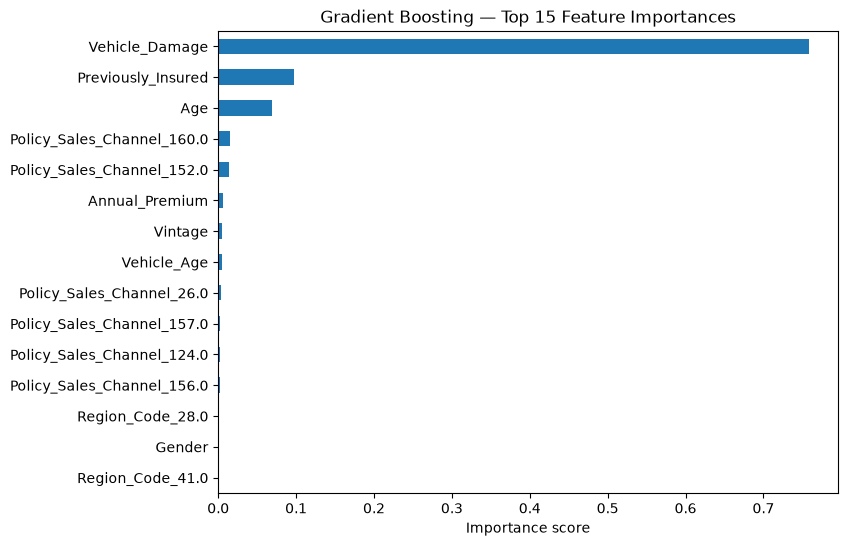

In [8]:
gb_importances = pd.Series(gb.feature_importances_, index=x.columns).sort_values(ascending=False)
gb_importances.head(15).plot(kind="barh", figsize=(8, 6),
                             title="Gradient Boosting — Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.xlabel("Importance score")
plt.show()

## Classification Threshold Analysis

ROC-AUC and Average Precision summarize performance across all cutoffs, but precision,
recall, and F1 depend on the threshold actually chosen. Rather than picking a value by
hand, three operating points are compared: the default 0.50 used for model comparison,
the threshold maximizing F1, which weights precision and recall equally, and the
threshold maximizing F2, which weights recall four times as heavily and aligns with the
goal of reaching as many interested customers as possible.


In [9]:
from sklearn.metrics import precision_recall_curve

gb_auc = roc_auc_score(y_test, gb_prob)

def evaluate_threshold(t):
    pred = (gb_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"Threshold = {t:.3f}")
    print(f"  ROC-AUC:   {gb_auc:.3f}  (constant)")
    print(f"  Precision: {precision_score(y_test, pred):.3f}")
    print(f"  Recall:    {recall_score(y_test, pred):.3f}")
    print(f"  F1:        {f1_score(y_test, pred):.3f}")
    print(f"  Contacted: {tp+fp:,}  |  Buyers reached: {tp:,} of {tp+fn:,}")
    print()

prec, rec, thr = precision_recall_curve(y_test, gb_prob)
prec, rec = prec[:-1], rec[:-1]
f1 = 2 * prec * rec / (prec + rec + 1e-12)
f2 = 5 * prec * rec / (4 * prec + rec + 1e-12)

for name, t in [("Default", 0.50),
                ("Max F1", thr[f1.argmax()]),
                ("Max F2", thr[f2.argmax()])]:
    print(name)
    evaluate_threshold(t)

Default
Threshold = 0.500
  ROC-AUC:   0.857  (constant)
  Precision: 0.287
  Recall:    0.919
  F1:        0.437
  Contacted: 29,934  |  Buyers reached: 8,584 of 9,342

Max F1
Threshold = 0.665
  ROC-AUC:   0.857  (constant)
  Precision: 0.326
  Recall:    0.771
  F1:        0.459
  Contacted: 22,083  |  Buyers reached: 7,205 of 9,342

Max F2
Threshold = 0.491
  ROC-AUC:   0.857  (constant)
  Precision: 0.285
  Recall:    0.923
  F1:        0.436
  Contacted: 30,222  |  Buyers reached: 8,626 of 9,342



**Threshold conclusion:** The default 0.50 cutoff is retained for model comparison so
all three algorithms are evaluated on equal terms. The F1-optimal point trades recall
for precision, while the F2-optimal point moves the other way and reaches more buyers
at the cost of additional wasted contacts. Because a missed sale costs more than a
declined email, the F2 point is the better fit for the cross-sell objective, though the
right choice ultimately depends on the outreach budget.

Note that these probabilities come from a model trained with balanced sample weights,
which inflates them toward the minority class. A cutoff of 0.50 here already
corresponds to roughly the 12% base rate on the unweighted scale, so thresholds are not
directly comparable to those of an unweighted model.


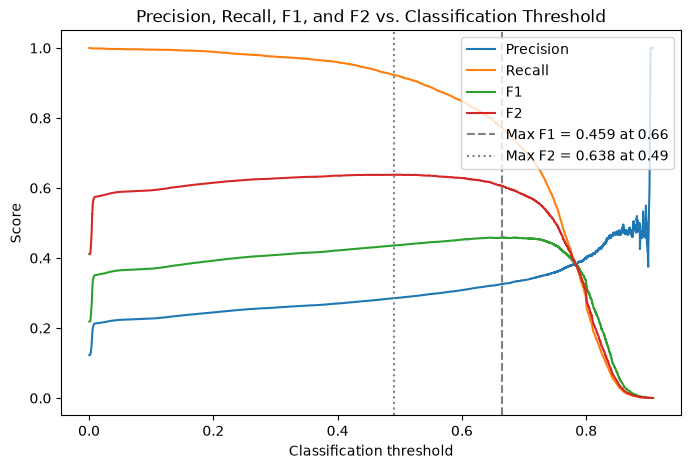

In [13]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, gb_prob)
prec, rec = prec[:-1], rec[:-1]
f1 = 2 * prec * rec / (prec + rec + 1e-12)
f2 = 5 * prec * rec / (4 * prec + rec + 1e-12)

plt.figure(figsize=(8, 5))
plt.plot(thr, prec, label="Precision")
plt.plot(thr, rec, label="Recall")
plt.plot(thr, f1, label="F1")
plt.plot(thr, f2, label="F2")
plt.axvline(thr[f1.argmax()], color="gray", ls="--",
            label=f"Max F1 = {f1.max():.3f} at {thr[f1.argmax()]:.2f}")
plt.axvline(thr[f2.argmax()], color="gray", ls=":",
            label=f"Max F2 = {f2.max():.3f} at {thr[f2.argmax()]:.2f}")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1, and F2 vs. Classification Threshold")
plt.legend()
plt.show()


### What the Curves Tell Us

Precision and recall pull against each other across the whole range, so no single cutoff
is right on its own. F1 peaks at [X], treating both equally. F2 peaks lower at [Y],
since it counts recall four times as heavily and accepts more false alarms to catch more
buyers.

F2 fits this campaign better. A declined email costs almost nothing, while a missed
buyer is lost revenue. We still report 0.50 so all three models can be compared on the
same footing.
